In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Carga con columnas específicas para no saturar la memoria
cols = ['ten_viv', 'region', 'ind_hacina', 'yinv_pbs', 'v2', 'v4']
df = pd.read_stata("../data/raw/casen_2024.dta", columns=cols, convert_categoricals=False)

# 2. Estandarización según metodología del profe
df.rename(columns={'ten_viv': 'TENENCIA', 'ind_hacina': 'HACINAMIENTO', 'yinv_pbs': 'SUBSIDIO'}, inplace=True)

# 3. Filtro de Propietarios (1: Pagada, 2: Pagándose)
df_final = df[df['TENENCIA'].isin([1, 2])].copy()

# 4. Limpieza de Nulos en Subsidios (Métricas bien obtenidas)
df_final['SUBSIDIO'] = df_final['SUBSIDIO'].fillna(0)

# 5. Crear ID Único (Metodología Profe)
df_final["ID_HOGAR"] = range(0, df_final.shape[0])

# 6. Agregación Compleja por Región
analisis_regional = df_final.groupby("region").agg({
    "HACINAMIENTO": ["mean", "max"],
    "SUBSIDIO": "mean",
    "ID_HOGAR": "count"
})

# Aplanamos los nombres de las columnas para graficar fácil
analisis_regional.columns = ['Hacinamiento_Promedio', 'Hacinamiento_Max', 'Subsidio_Promedio', 'Total_Propietarios']
analisis_regional = analisis_regional.reset_index()

print(f"Dataset listo: {df_final.shape[0]} propietarios procesados.")

Dataset listo: 177746 propietarios procesados.


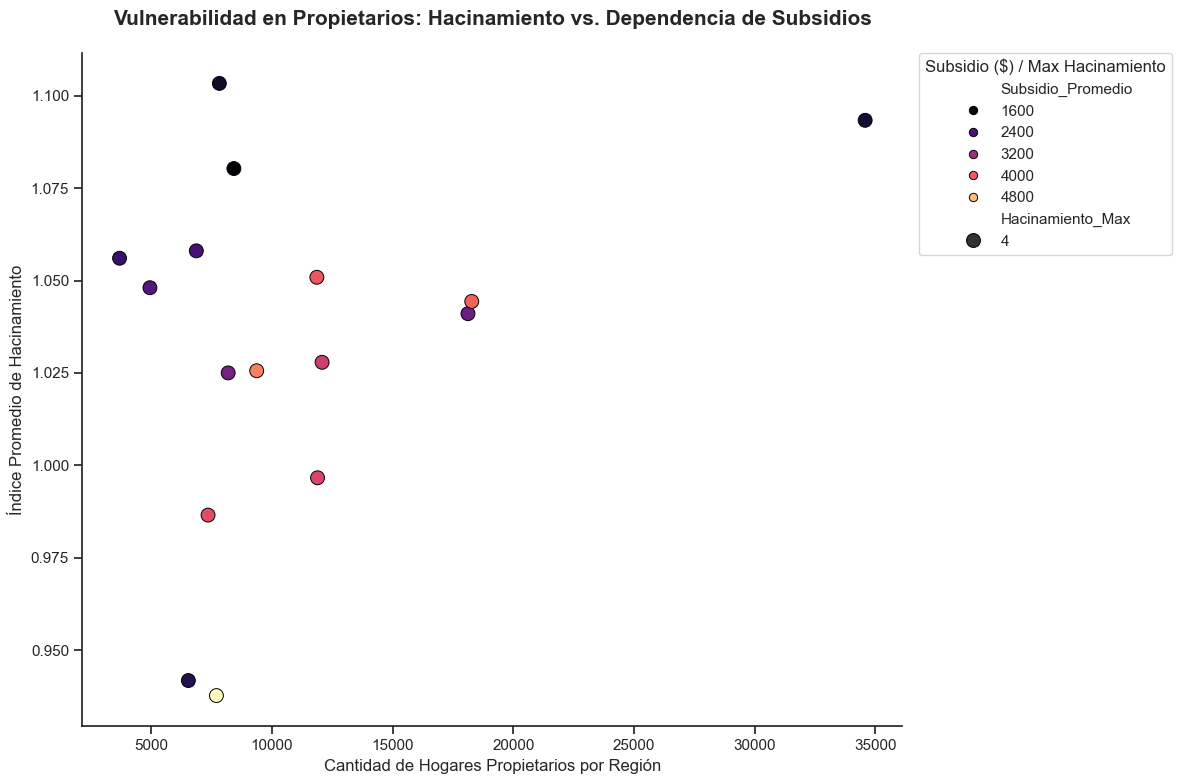

In [23]:
# Configuración de estilo (Calidad de figuras: consistencia)
sns.set_theme(style="ticks")
plt.figure(figsize=(12, 8))

# Gráfico Scatter con 4 dimensiones: X, Y, Color (Subsidio) y Tamaño (Max Hacinamiento)
plot = sns.scatterplot(
    data=analisis_regional, 
    x="Total_Propietarios", 
    y="Hacinamiento_Promedio", 
    hue="Subsidio_Promedio", 
    palette="magma",       # Paleta con mejor contraste que 'Reds'
    size="Hacinamiento_Max", 
    sizes=(100, 500),      # Puntos más grandes para mejor visibilidad
    edgecolor="black",     # Borde para que no se pierdan puntos claros
    linewidth=0.7
)

# Títulos claros para audiencia no especializada (1.5 pts)
plt.title("Vulnerabilidad en Propietarios: Hacinamiento vs. Dependencia de Subsidios", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Cantidad de Hogares Propietarios por Región", fontsize=12)
plt.ylabel("Índice Promedio de Hacinamiento", fontsize=12)

# Leyenda fuera del gráfico para evitar el desorden (Anti-clutter)
plt.legend(title="Subsidio ($) / Max Hacinamiento", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

# Limpieza de bordes
sns.despine()
plt.tight_layout()

# Guardar para tu página A4
# plt.savefig("grafico1_complejidad.png", dpi=300)
plt.show()

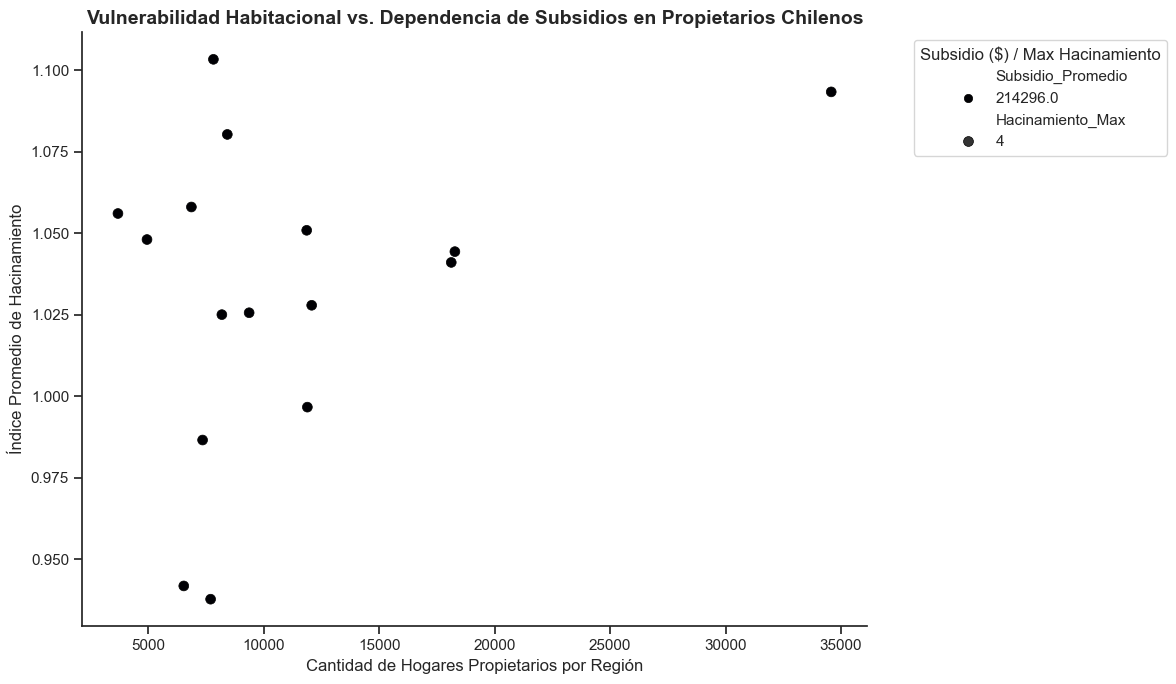

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configurar un tema más limpio (Metodología Profe: set_theme)
sns.set_theme(style="ticks") # 'ticks' elimina la grilla interior que confunde

# 2. Crear la figura (Calidad de figuras: tamaño consistente)
plt.figure(figsize=(12, 7))

# 3. Crear el gráfico con ESCALA DE COLOR SECUENCIAL Mejorada
# Usamos 'inferno' que es secuencial pero tiene mejor contraste
plot = sns.scatterplot(
    data=analisis_regional, 
    x="Total_Propietarios", 
    y="Hacinamiento_Promedio", 
    hue="Subsidio_Promedio", 
    palette="inferno", # CAMBIO CLAVE: Mejor visibilidad en todo el rango
    size="Hacinamiento_Max", # Agregamos una 4ta variable (Complejidad: 2 pts)
    sizes=(50, 400), # Tamaño de los puntos
    edgecolor="black", # Agregamos borde negro para definir los puntos
    linewidth=0.5
)

# 4. Títulos claros para audiencia no especializada (Mensaje Claro: 1.5 pts)
plt.title("Vulnerabilidad Habitacional vs. Dependencia de Subsidios en Propietarios Chilenos", fontsize=14, fontweight='bold')
plt.xlabel("Cantidad de Hogares Propietarios por Región", fontsize=12)
plt.ylabel("Índice Promedio de Hacinamiento", fontsize=12)

# 5. Ajustar leyendas para que no tapen (pauta: contenido útil)
plt.legend(title="Subsidio ($) / Max Hacinamiento", bbox_to_anchor=(1.05, 1), loc='upper left')

# 6. Eliminar bordes innecesarios (despine)
sns.despine()

plt.tight_layout()
plt.show()

In [18]:
# Mapeo de materialidad según el libro de códigos (ajustar según tu Excel)
# Generalmente 1 es 'Sólido/Bueno' y valores altos son 'Precario/Tierra'
df_final['Calidad_Muros'] = df_final['v2'].apply(lambda x: 'Aceptable' if x == 1 else 'Precario')
df_final['Calidad_Piso'] = df_final['v4'].apply(lambda x: 'Aceptable' if x == 1 else 'Precario')

# Agrupamos para ver la frecuencia (Metodología Profe)
materialidad_resumen = df_final.groupby(['region', 'Calidad_Muros']).size().reset_index(name='Total')

c:\Users\sebyt\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\sebyt\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


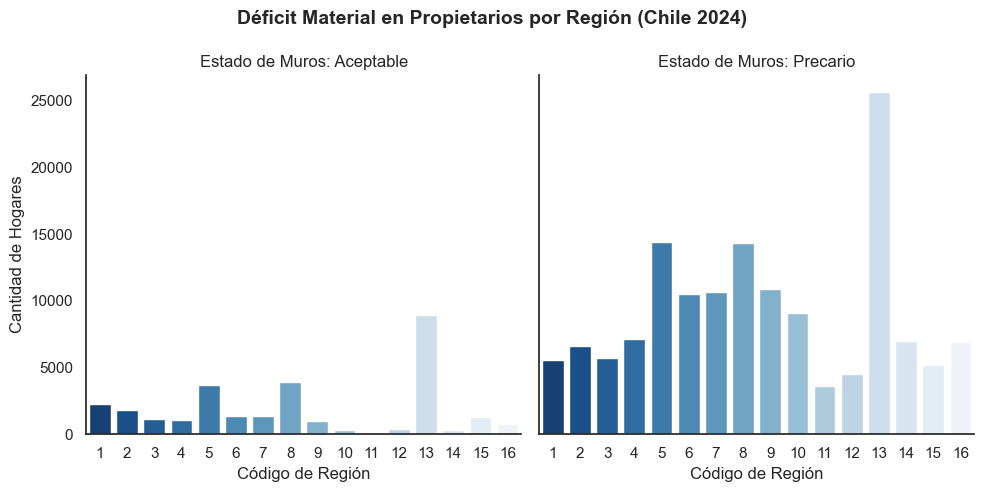

In [19]:
# Configuración de estilo consistente (1 pt de calidad visual)
sns.set_theme(style="white")

# Crear el FacetGrid
g = sns.FacetGrid(materialidad_resumen, col="Calidad_Muros", height=5, aspect=1)

# Aplicar el gráfico de barras con una ESCALA DE COLOR SECUENCIAL (Blues)
g.map_dataframe(sns.barplot, x="region", y="Total", palette="Blues_r")

# Ajustar títulos y etiquetas (Mensaje claro: 1.5 pts)
g.set_axis_labels("Código de Región", "Cantidad de Hogares")
g.set_titles(col_template="Estado de Muros: {col_name}")

# Añadir título general al final
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Déficit Material en Propietarios por Región (Chile 2024)', fontsize=14, fontweight='bold')

plt.show()

C:\Users\sebyt\AppData\Local\Temp\ipykernel_20348\3994553291.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.boxplot(


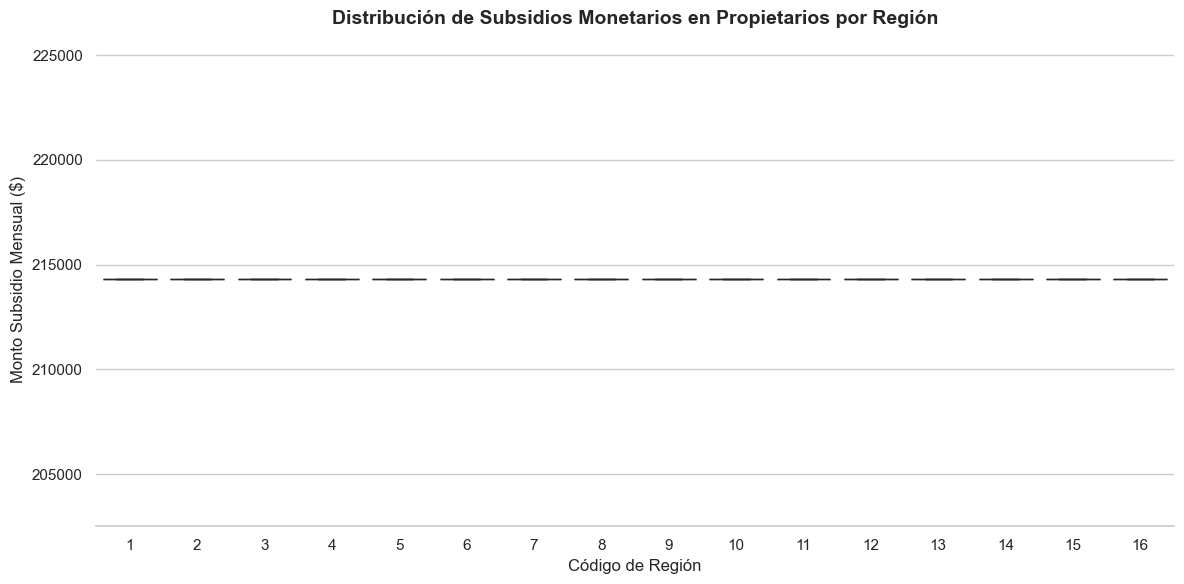

In [20]:
# 1. Configuración de estilo consistente (1 pt de calidad visual)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 2. Crear el Boxplot (Análisis de Outliers y Distribución)
# Filtramos valores mayores a 0 para ver realmente a los beneficiarios
subsidios_activos = df_final[df_final['yinv_pbs'] > 0]

plot = sns.boxplot(
    data=subsidios_activos,
    x='region',
    y='yinv_pbs',
    palette='viridis', # Escala de color diferente
    fliersize=3,       # Tamaño de los puntos outliers
    linewidth=1
)

# 3. Títulos para audiencia no especializada (1.5 pts)
plt.title('Distribución de Subsidios Monetarios en Propietarios por Región', fontsize=14, fontweight='bold')
plt.xlabel('Código de Región', fontsize=12)
plt.ylabel('Monto Subsidio Mensual ($)', fontsize=12)

# 4. Limpieza visual (Ugly, Bad, Wrong)
sns.despine(left=True)
plt.tight_layout()
plt.show()

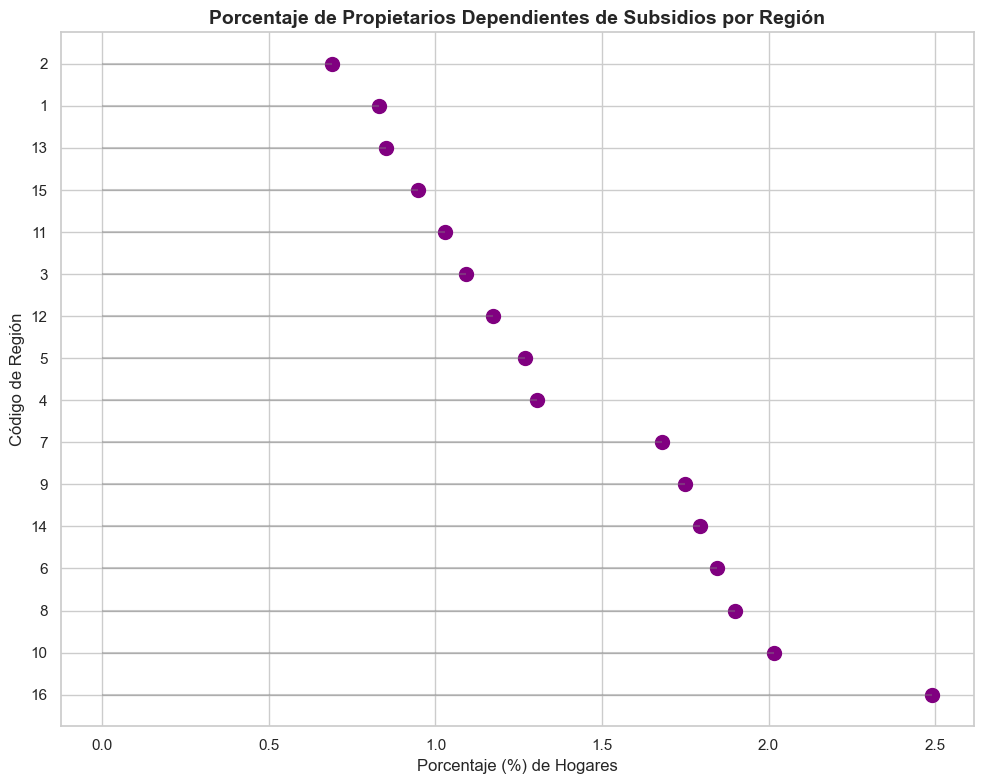

In [21]:
# 1. Preparar la métrica (Transformación de datos para Complejidad)
# Calculamos el % de propietarios que reciben el subsidio yinv_pbs por región
dep_subsidio = df_final.groupby('region').agg(
    total=('ID_HOGAR', 'count'),
    con_subsidio=('yinv_pbs', lambda x: (x > 0).sum())
)
dep_subsidio['porcentaje'] = (dep_subsidio['con_subsidio'] / dep_subsidio['total']) * 100
dep_subsidio = dep_subsidio.sort_values('porcentaje', ascending=False).reset_index()

# 2. Configuración visual
plt.figure(figsize=(10, 8))
plt.hlines(y=dep_subsidio.index, xmin=0, xmax=dep_subsidio['porcentaje'], color='grey', alpha=0.4)

# 3. El punto del Lollipop con ESCALA DE COLOR SECUENCIAL (Viridis)
plt.scatter(dep_subsidio['porcentaje'], dep_subsidio.index, color='purple', s=100, alpha=1)

# 4. Estética y Títulos (Mensaje claro para audiencia no especializada)
plt.yticks(dep_subsidio.index, dep_subsidio['region'])
plt.title('Porcentaje de Propietarios Dependientes de Subsidios por Región', fontsize=14, fontweight='bold')
plt.xlabel('Porcentaje (%) de Hogares', fontsize=12)
plt.ylabel('Código de Región', fontsize=12)

plt.tight_layout()
plt.show()